In [1]:
import torch
import torch.nn as nn
import lightning.pytorch as pl
from lightning.pytorch import loggers as pl_loggers

import numpy as np
from matplotlib import pyplot as plt

In [2]:
class BaseLineNetwork(pl.LightningModule):

    def __init__(self):
        super(BaseLineNetwork, self).__init__()

        self.lr = 1e-3
        self.example_input_array = torch.rand(1, 5, 128, 64)

        self.network = nn.Sequential(
            nn.Conv2d(in_channels=5, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=64, out_channels=5, kernel_size=3, padding=1),
        )
    
    def forward(self, x):
        return self.network(x)
    
    def training_step(self, batch, batch_idx):
        x, y = batch

        y_hat = self(x)

        loss = nn.functional.mse_loss(y_hat, y)

        self.log('train_loss', loss, on_epoch=True)

        return loss
    
    def validation_step(self, batch, batch_idx):
        x, y = batch

        y_hat = self(x)

        loss = nn.functional.mse_loss(y_hat, y)

        self.log('val_loss', loss, on_epoch=True)
    
    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.lr)

        return {
            'optimizer': optimizer
        }

In [3]:
class BaseLineDataset(torch.utils.data.Dataset):

    def __init__(self, path: str):
        super(BaseLineDataset, self).__init__()

        self.path = path

        self.mean: np.ndarray = np.array([5.4008180e+04, 2.7393976e+02, 2.3674958e-03, 2.7760931e+02, 6.2221546e+00], dtype=np.float32)
        self.std: np.ndarray = np.array([3.3518201e+03, 1.5841744e+01, 2.4138752e-03, 2.1723423e+01, 3.4207888e+00], dtype=np.float32)
        
        self.data = self._load_data()

    def _load_data(self) -> np.ndarray:
        path = self.path
        c = 5
        w, h = 128, 64

        data = np.memmap(path, mode="r", dtype=np.float32).reshape(-1, c, w, h)

        return data
    
    def denormalize_sample(self, sample: np.ndarray) -> np.ndarray:
        return sample * self.std[:, None, None] + self.mean[:, None, None]

    def __len__(self):
        return len(self.data) - 1

    def __getitem__(self, idx):

        item_1 = self.data[idx]
        item_2 = self.data[idx + 1]

        # normalize
        item_1 = (item_1 - self.mean[:, None, None]) / self.std[:, None, None]
        item_2 = (item_2 - self.mean[:, None, None]) / self.std[:, None, None]

        return item_1, item_2

In [4]:
def train():

    model = BaseLineNetwork()
    train_ds = BaseLineDataset(path="train.memmap")
    val_ds = BaseLineDataset(path="val.memmap")

    train_dataloader = torch.utils.data.DataLoader(
        train_ds,
        batch_size=256,
        shuffle=False,
    )

    val_dataloader = torch.utils.data.DataLoader(
        val_ds,
        batch_size=256,
        shuffle=False,
    )

    tb_logger = pl_loggers.TensorBoardLogger(
        save_dir="logs/", name="baseline")

    trainer = pl.Trainer(
        logger=tb_logger,
        max_epochs=-1
    )

    trainer.fit(
        model=model,
        train_dataloaders=train_dataloader,
        val_dataloaders=val_dataloader
    )

# train()

In [5]:
model = BaseLineNetwork.load_from_checkpoint("weights/baseline.ckpt").to("cpu")
model.eval()
model.freeze()

dataset = BaseLineDataset(path="val.memmap")

print(dataset.data.shape)

(9204, 5, 128, 64)


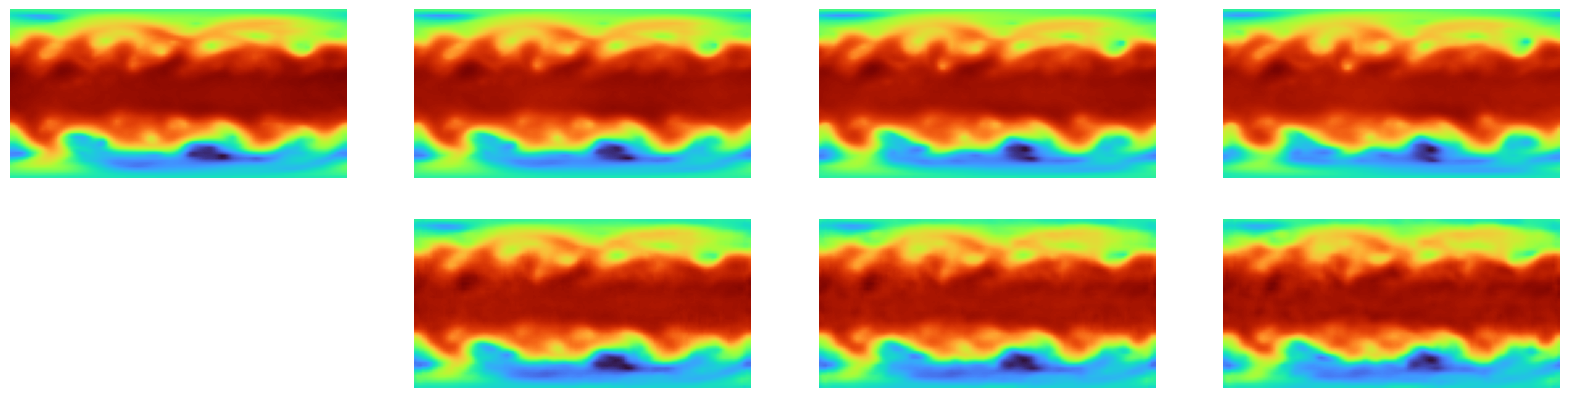

RMSE: 181.7853240966797


In [6]:
x, y = dataset[0]
_, y_2 = dataset[1]
_, y_3 = dataset[2]

x_t = torch.tensor(x).unsqueeze(0)

y_hat_1 = model(x_t)
y_hat_2 = model(y_hat_1)
y_hat_3 = model(y_hat_2)

feature = 0

fig, axs = plt.subplots(2, 4, figsize=(20, 5))

axs[0, 0].imshow(x[feature].T, origin="lower", cmap="turbo")
axs[0, 0].axis("off")

axs[0, 1].imshow(y[feature].T, origin="lower", cmap="turbo")
axs[0, 1].axis("off")

axs[0, 2].imshow(y_2[feature].T, origin="lower", cmap="turbo")
axs[0, 2].axis("off")

axs[0, 3].imshow(y_3[feature].T, origin="lower", cmap="turbo")
axs[0, 3].axis("off")

axs[1, 0].axis("off")

axs[1, 1].imshow(y_hat_1[0, feature].detach().numpy().T, origin="lower", cmap="turbo")
axs[1, 1].axis("off")

axs[1, 2].imshow(y_hat_2[0, feature].detach().numpy().T, origin="lower", cmap="turbo")
axs[1, 2].axis("off")

axs[1, 3].imshow(y_hat_3[0, feature].detach().numpy().T, origin="lower", cmap="turbo")
axs[1, 3].axis("off")

plt.show()

denorm_y = dataset.denormalize_sample(y)
denorm_y_hat_1 = dataset.denormalize_sample(y_hat_1[0].detach().numpy())

rmse = np.sqrt(np.mean((denorm_y[feature] - denorm_y_hat_1[feature]) ** 2))
print(f"RMSE: {rmse}")

In [7]:
import xarray as xr

def compute_weighted_rmse(da_fc, da_true, mean_dims=xr.ALL_DIMS):
    """
    Compute the RMSE with latitude weighting from two xr.DataArrays.

    Args:
        da_fc (xr.DataArray): Forecast. Time coordinate must be validation time.
        da_true (xr.DataArray): Truth.
        mean_dims: dimensions over which to average score
    Returns:
        rmse: Latitude weighted root mean squared error
    """
    error = da_fc - da_true
    weights_lat = np.cos(np.deg2rad(error.lat))
    weights_lat /= weights_lat.mean()
    rmse = np.sqrt(((error)**2 * weights_lat).mean(mean_dims))
    return rmse

def np_to_xr(data_np: np.ndarray, feature: int) -> xr.DataArray:
    lat = np.linspace(-90, 90, 64)
    lon = np.linspace(0, 360, 128)

    return xr.DataArray(
        data=data_np[feature],
        dims=["lon", "lat"],
        coords={"lon": lon, "lat": lat}
    )

da_true = np_to_xr(denorm_y, feature)
da_fc = np_to_xr(denorm_y_hat_1, feature)

rmse = compute_weighted_rmse(da_fc, da_true)
print(f"RMSE: {rmse}")

RMSE: <xarray.DataArray ()>
array(162.96883262)


In [36]:
# Calculate Persistence RMSE

feature = 0
num_samples = 1000
forecast_steps = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
values = []

for s in forecast_steps:

    persistence_rmse = 0

    for i in range(num_samples):

        index = np.random.randint(0, len(dataset) - s)

        gt, _ = dataset[index]
        gt = dataset.denormalize_sample(gt)
        da_gt = np_to_xr(gt, feature)

        forecast, _ = dataset[index + s]
        forecast = dataset.denormalize_sample(forecast)
        da_forecast = np_to_xr(forecast, feature)

        persistence_rmse += compute_weighted_rmse(da_forecast, da_gt)

    persistence_rmse /= num_samples
    values.append(persistence_rmse)
    print(f"Persistence RMSE: {persistence_rmse}")

KeyboardInterrupt: 

In [ ]:
print([round(item.item(), 2) for item in values])

In [ ]:
with torch.no_grad():

    # Calculate Baseline RMSE

    feature = 0
    num_samples = 1000
    forecast_steps = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
    values = []

    for s in forecast_steps:

        baseline_rmse = 0

        for i in range(num_samples):

            index = np.random.randint(0, len(dataset) - s)

            start, _ = dataset[index]
            start = torch.Tensor(start).unsqueeze(0)

            for _ in range(s):
                start = model(start)

            forecast = start.squeeze(0).detach().numpy()
            forecast = dataset.denormalize_sample(forecast)
            da_forecast = np_to_xr(forecast, feature)

            gt, _ = dataset[index + s]
            gt = dataset.denormalize_sample(gt)
            da_gt = np_to_xr(gt, feature)

            baseline_rmse += compute_weighted_rmse(da_forecast, da_gt)   

        baseline_rmse /= num_samples
        values.append(baseline_rmse)
        print(f"Persistence RMSE: {baseline_rmse}")

In [10]:
### TEMPORÄR ###
from models.vqvae import VQVAE
from models.vqvae_2 import VQVAE2
from models.resnet import ResNet

from torch.optim.lr_scheduler import ReduceLROnPlateau

class LatentNetwork(pl.LightningModule):
    def __init__(self, in_channels: int, lr: float, vqvae: VQVAE):
        super(LatentNetwork, self).__init__()

        self.save_hyperparameters()

        self.lr = lr
        self.example_input_array = torch.rand(1, 4, 16, 8)

        self.vqvae = vqvae
        self.quantize_loss_weight = 0.1

        self.vqvae.freeze()
        self.vqvae.eval()

        self.in_channels = in_channels

        self.network = nn.Sequential(
            nn.Conv2d(in_channels=self.in_channels, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=64, out_channels=self.in_channels, kernel_size=3, padding=1),
        )

        # self.network = ResNet(in_channels=8)

    def forward(self, x):

        out = self.network(x)

        return out
    
    def training_step(self, batch, batch_idx):
        x_1, x_2 = batch

        pred = self(x_1)
        pred_quantized, quantize_loss_1, _ = self.vqvae.quantize(pred)

        prediction_loss = torch.nn.functional.mse_loss(pred_quantized, x_2)
        commitment_loss = quantize_loss_1["commitment_loss"]

        loss = prediction_loss + self.quantize_loss_weight * commitment_loss

        self.log('train_loss', loss, prog_bar=True)

        return loss

    def validation_step(self, batch, batch_idx):
        x_1, x_2 = batch

        pred = self(x_1)
        pred_quantized, quantize_loss_1, _ = self.vqvae.quantize(pred)

        prediction_loss = torch.nn.functional.mse_loss(pred_quantized, x_2)
        commitment_loss = quantize_loss_1["commitment_loss"]

        loss = prediction_loss + self.quantize_loss_weight * commitment_loss

        self.log('val_loss', loss)

        return loss

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.lr)
        lr_scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, verbose=True)

        return {"optimizer": optimizer, "lr_scheduler": {"scheduler": lr_scheduler, "monitor": "val_loss"}}


In [28]:
with torch.no_grad():
    
    # calculate RMSE for the latent model

    device = "cuda" if torch.cuda.is_available() else "cpu"
    vqvae_checkpoint = "logs/vqvae_dim4_c8192/version_0/checkpoints/epoch=11-step=27612.ckpt"
    resnet_checkpoint = "logs/forecastnet_direct_72h_full_ds_with_lr_scheduler/version_0/checkpoints/epoch=75-step=5472.ckpt"
    # resnet_checkpoint = "weights/resnet.pth"

    vqvae = VQVAE2.load_from_checkpoint(vqvae_checkpoint).to(device)
    vqvae.eval()

    resnet = LatentNetwork.load_from_checkpoint(resnet_checkpoint)
    resnet.eval()
    # resnet = ResNet(in_channels=8).to(device)
    # resnet.load_state_dict(torch.load(resnet_checkpoint))

    feature = 0
    num_samples = 200
    forecast_steps = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
    values = []

    for s in forecast_steps:

        latent_rmse = 0

        for i in range(num_samples):

            index = np.random.randint(0, len(dataset) - s)

            start, _ = dataset[index]
            start = torch.Tensor(start).unsqueeze(0)

            _, latent, _ = vqvae(start.to(device))
            
            for _ in range(s):
                latent = resnet(latent)
                latent, _, _ = vqvae.quantize(latent)

            forecast = vqvae.decode(latent)
            forecast = forecast.squeeze(0).detach().cpu().numpy()
            forecast = dataset.denormalize_sample(forecast)

            da_forecast = np_to_xr(forecast, feature)
            
            gt, _ = dataset[index + s]
            gt = dataset.denormalize_sample(gt)
            da_gt = np_to_xr(gt, feature)

            latent_rmse += compute_weighted_rmse(da_forecast, da_gt)

        latent_rmse /= num_samples
        values.append(latent_rmse)
        print(f"Latent RMSE: {latent_rmse}")

print([round(item.item(), 2) for item in values])
            

c:\Users\hendr\miniconda3\envs\pytorch_light\Lib\site-packages\lightning\pytorch\utilities\parsing.py:208: Attribute 'vqvae' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['vqvae'])`.


Latent RMSE: <xarray.DataArray ()>
array(695.43097219)


KeyboardInterrupt: 

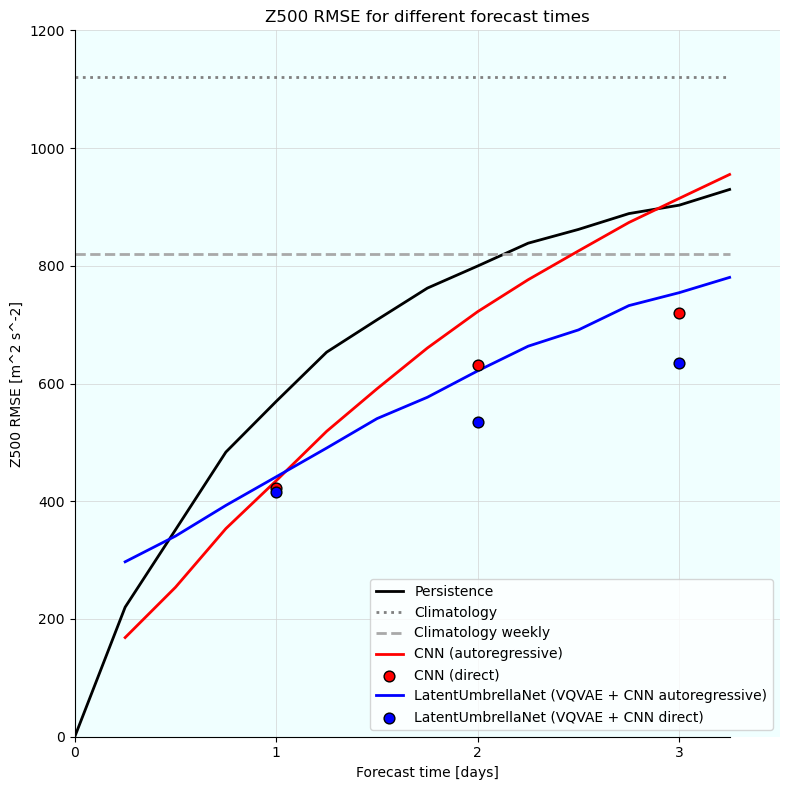

In [3]:
time = np.linspace(0, 3.25, 14)
persistence = [0, 220.11, 351.61, 483.59, 569.74, 653.3, 708.21, 762.1, 799.69, 838.4, 861.83, 888.68, 902.99, 929.7]
climatology = np.ones_like(time) * 1120
climatology_weekly = np.ones_like(time) * 820
cnn = [168.47, 253.97, 353.58, 435.05, 518.84, 591.09, 660.36, 722.21, 776.36, 825.33, 873.55, 914.53, 955.13]
# lun = [238.0, 302.29, 347.12, 397.29, 456.87, 483.74, 503.89, 534.68, 579.85, 594.01, 653.85, 667.76, 704.96]
# lun = [316.75, 378.72, 454.43, 520.99, 574.69, 647.71, 678.19, 755.44, 764.5, 807.95, 894.77, 904.29, 941.6]
# lun = [317.62, 376.64, 441.42, 503.1, 550.75, 604.32, 661.34, 703.79, 743.75, 774.96, 813.58, 845.04, 863.63]
lun = [297.16, 340.88, 392.99, 441.61, 490.41, 540.43, 576.67, 621.59, 663.42, 691.11, 732.38, 754.36, 780.3]

#set plot size
plt.figure(figsize=(8, 8))

plt.plot(time, persistence, label="Persistence", color="black", linestyle="-", linewidth=2)
plt.plot(time, climatology, label="Climatology", color="gray", linestyle="dotted", linewidth=2)
plt.plot(time, climatology_weekly, label="Climatology weekly", color="darkgray", linestyle="--", linewidth=2)
plt.plot(time[1:], cnn, label="CNN (autoregressive)", color="red", linestyle="-", linewidth=2)
plt.scatter([1], [423], color="red", marker="o", s=60, edgecolors="black", linewidths=1, zorder=3)
plt.scatter([2], [631], color="red", marker="o", s=60, edgecolors="black", linewidths=1, zorder=3, label="CNN (direct)")
plt.scatter([3], [720], color="red", marker="o", s=60, edgecolors="black", linewidths=1, zorder=3)
plt.plot(time[1:], lun, label="LatentUmbrellaNet (VQVAE + CNN autoregressive)", color="blue", linestyle="-", linewidth=2)
plt.scatter([1], [416], color="blue", marker="o", s=60, edgecolors="black", linewidths=1, zorder=4)
plt.scatter([2], [534], color="blue", marker="o", s=60, edgecolors="black", linewidths=1, zorder=4)
plt.scatter([3], [635], color="blue", marker="o", s=60, edgecolors="black", linewidths=1, zorder=4, label="LatentUmbrellaNet (VQVAE + CNN direct)")
# plt.plot(time[1:], lun2, label="LatentUmbrellaNet (VQVAE + CNN) 2", color="orange", linestyle="-", linewidth=2)

plt.xticks([0, 1, 2, 3])
plt.xlim(0, 3.5)
plt.xlabel("Forecast time [days]")

plt.yticks([0, 200, 400, 600, 800, 1000, 1200])
plt.ylim(0, 1200)
plt.ylabel("Z500 RMSE [m^2 s^-2]")

plt.title("Z500 RMSE for different forecast times")

plt.legend()

plt.grid(
    axis="both",
    linestyle="-",
    linewidth=0.5,
    color="lightgray",
    which="major"
)

# remove borders
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

# more fancy plot
plt.gca().spines["left"].set_bounds(0, 1200)
plt.gca().spines["bottom"].set_bounds(0, 3.25)

# tight layout
plt.tight_layout()

# background color light gray
plt.gca().set_facecolor("azure")
